<a href="https://colab.research.google.com/github/prachiandhale/The-Predictors/blob/main/Model%20Train_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully")

In [8]:
File_Name = "FakeNewsDetector.csv"
df = pd.read_csv('FakeNewsDetector.csv')
print("Dataset loaded successfully")
print("Shape:",df.shape)

Dataset loaded successfully
Shape: (2000, 16)


In [10]:
print("First Five Rows")
df.head()

First Five Rows


,id,title,text,label,category,source_type,author,publication_date,country,language,word_count,has_source,credibility_score,shares,likes,comments
0,1,Government announces new scholarship program f...,According to an update shared by relevant orga...,REAL,Technology,Official/Reported,Author_7,2026-05-08,USA,English,32,True,0.78,13444,71487,1424
1,2,Scientists discover a new method to improve so...,According to an update shared by relevant orga...,REAL,Weather,Official/Reported,Author_9,2026-01-03,USA,English,34,True,0.81,78917,3483,9195
2,3,Local university opens a new artificial intell...,Officials and researchers have reported an upd...,REAL,Weather,Official/Reported,Author_57,2026-08-19,UK,English,40,True,0.94,861,20931,11438
3,4,New public transport route launched to connect...,A recent report discusses new public transport...,REAL,Business,Official/Reported,Author_72,2026-03-07,UK,English,29,True,0.77,49807,12681,5881
4,5,Researchers publish study on reducing plastic ...,A recent report discusses researchers publish ...,REAL,Health,Official/Reported,Author_12,2026-08-18,India,English,29,True,0.98,49625,10333,9044


In [11]:
print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   title              2000 non-null   object 
 2   text               2000 non-null   object 
 3   label              2000 non-null   object 
 4   category           2000 non-null   object 
 5   source_type        2000 non-null   object 
 6   author             2000 non-null   object 
 7   publication_date   2000 non-null   object 
 8   country            2000 non-null   object 
 9   language           2000 non-null   object 
 10  word_count         2000 non-null   int64  
 11  has_source         2000 non-null   bool   
 12  credibility_score  2000 non-null   float64
 13  shares             2000 non-null   int64  
 14  likes              2000 non-null   int64  
 15  comments           2000 non-null   int64  
dtypes: b

In [13]:
print("Dataset Column names")
df.columns

Dataset Column names


Index(['id', 'title', 'text', 'label', 'category', 'source_type', 'author',
       'publication_date', 'country', 'language', 'word_count', 'has_source',
       'credibility_score', 'shares', 'likes', 'comments'],
      dtype='object')

In [14]:
print("Check for missing values in dataset")
df.isnull().sum()

Check for missing values in dataset


,0
id,0
title,0
text,0
label,0
category,0
source_type,0
author,0
publication_date,0
country,0
language,0


In [15]:
print("Check for duplicate rows in the dataset")
df.duplicated().sum()

Check for duplicate rows in the dataset


np.int64(0)

In [16]:
print("Data Types")
df.dtypes

Data Types


,0
id,int64
title,object
text,object
label,object
category,object
source_type,object
author,object
publication_date,object
country,object
language,object


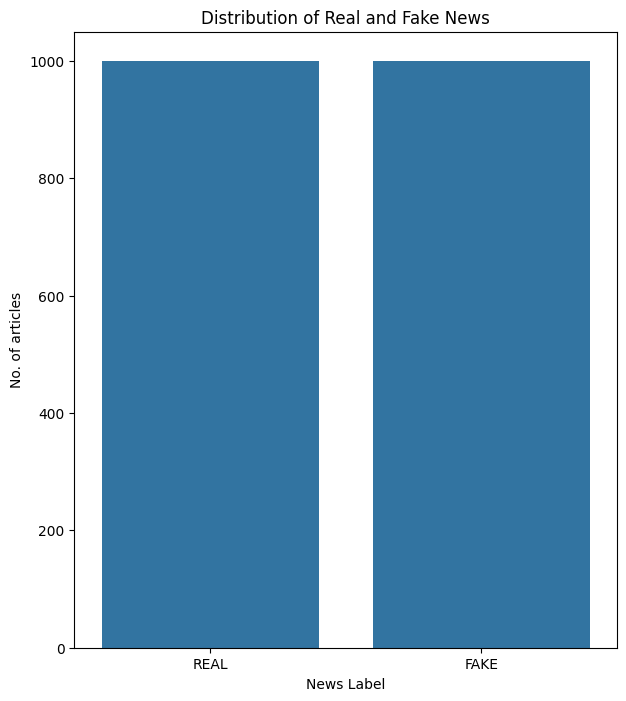

In [18]:
plt.figure(figsize=(7,8))
sns.countplot(data=df,x="label")
plt.title("Distribution of Real and Fake News")
plt.xlabel("News Label")
plt.ylabel("No. of articles")
plt.show()

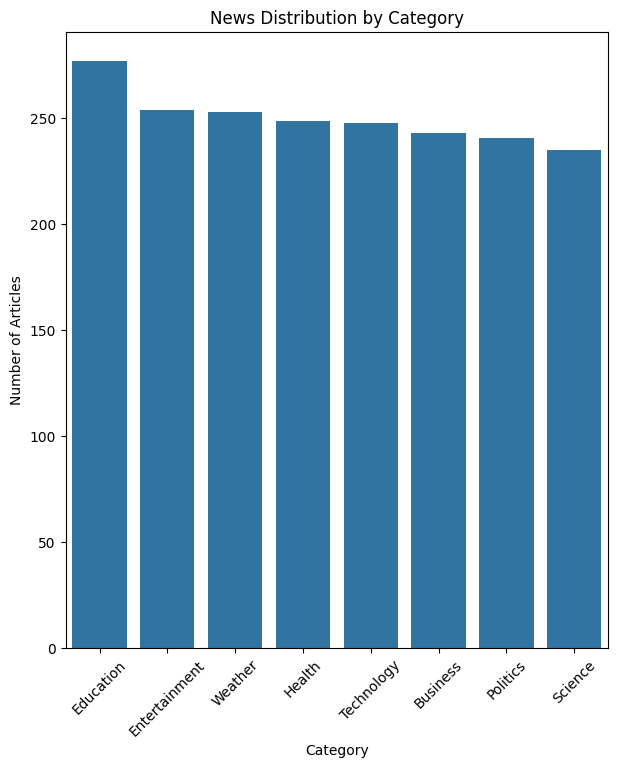

In [19]:
plt.figure(figsize=(7,8))
sns.countplot(data=df,x="category",
    order=df["category"].value_counts().index)

plt.title("News Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

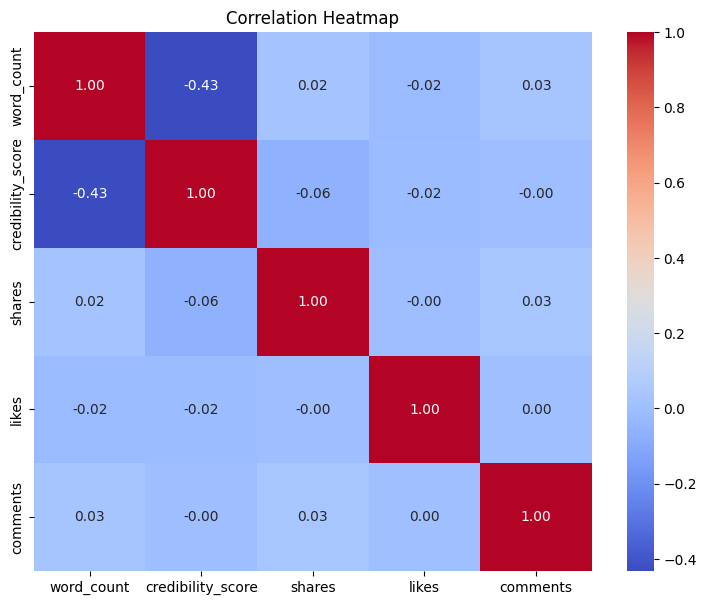

In [20]:
numeric_columns = [
    "word_count",
    "credibility_score",
    "shares",
    "likes",
    "comments"
]
correlation = df[numeric_columns].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
df["combined_text"] = (df["title"].fillna("") + " " + df["text"].fillna(""))
print(df["combined_text"].head())

X  = df["combined_text"]
y = df["label"]
print("Input features",X.shape)
print("target",y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
   random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

0    Government announces new scholarship program f...
1    Scientists discover a new method to improve so...
2    Local university opens a new artificial intell...
3    New public transport route launched to connect...
4    Researchers publish study on reducing plastic ...
Name: combined_text, dtype: object
Input features (2000,)
target (2000,)
Training samples: 1600
Testing samples: 400
